# 🎓 Student Exam Score Prediction — End-to-End ML Project

**Dataset:** Kaggle – Student Performance Factors (~6,600 rows, 20 columns)  
**Goal:** Predict a student's `Exam_Score` from study habits, attendance, lifestyle, and family background.  
**Audience:** Beginner-friendly — every code block is preceded by a plain-English explanation.

---

## Step 0 — Install & Import Libraries

We import everything we need upfront.  
- **pandas / numpy** → data manipulation  
- **matplotlib / seaborn** → visualisation  
- **scikit-learn** → preprocessing, models, evaluation  
- **shap** → model explainability  
- **joblib** → saving the trained pipeline to disk

In [1]:
# Install any missing packages (uncomment if running on Colab)
# !pip install shap xgboost -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Scikit-learn — preprocessing
from sklearn.model_selection import train_test_split, cross_validate, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-learn — models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Scikit-learn — metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# SHAP for model explainability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Skipping SHAP plots.')

# Reproducibility seed
RANDOM_STATE = 42

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Step 1 — Load & Inspect the Data

We read the CSV file into a pandas DataFrame and immediately check:
- **Shape** – how many rows and columns?
- **Column names & data types** – are they numeric or text?
- **Summary statistics** – mean, min, max, quartiles for numeric columns
- **Missing values** – any gaps we need to fill later?

We never hard-code column names here; we discover them from the file.

In [2]:
# ── Load the dataset ──────────────────────────────────────────────────────────
DATA_PATH = 'StudentPerformanceFactors.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\n── Column names ──')
print(df.columns.tolist())

Dataset shape: 6607 rows × 20 columns

── Column names ──
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [3]:
# First 5 rows — quick sanity check
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
# Data types of each column
print('── Data Types ──')
print(df.dtypes)

# Separate numeric vs categorical column names for later use
TARGET = 'Exam_Score'
NUMERIC_COLS   = df.select_dtypes(include=['int64','float64']).columns.drop(TARGET).tolist()
CATEGORICAL_COLS = df.select_dtypes(include=['object']).columns.tolist()

print(f'\nNumeric features   : {NUMERIC_COLS}')
print(f'Categorical features: {CATEGORICAL_COLS}')
print(f'Target             : {TARGET}')

── Data Types ──
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Numeric features   : ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',

In [5]:
# Summary statistics for numeric columns
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


In [6]:
# Missing values per column — critical to know before preprocessing
missing = df.isnull().sum().rename('Missing Count')
missing_pct = (df.isnull().mean() * 100).rename('Missing %').round(2)
missing_summary = pd.concat([missing, missing_pct], axis=1)
print(missing_summary[missing_summary['Missing Count'] > 0] if missing_summary['Missing Count'].sum() > 0
      else 'No missing values found in the dataset.')

                          Missing Count  Missing %
Teacher_Quality                      78       1.18
Parental_Education_Level             90       1.36
Distance_from_Home                   67       1.01


In [7]:
# Unique values for each categorical column — helps spot typos or weird categories
for col in CATEGORICAL_COLS:
    print(f'{col:30s}: {df[col].unique()}')

Parental_Involvement          : ['Low' 'Medium' 'High']
Access_to_Resources           : ['High' 'Medium' 'Low']
Extracurricular_Activities    : ['No' 'Yes']
Motivation_Level              : ['Low' 'Medium' 'High']
Internet_Access               : ['Yes' 'No']
Family_Income                 : ['Low' 'Medium' 'High']
Teacher_Quality               : ['Medium' 'High' 'Low' nan]
School_Type                   : ['Public' 'Private']
Peer_Influence                : ['Positive' 'Negative' 'Neutral']
Learning_Disabilities         : ['No' 'Yes']
Parental_Education_Level      : ['High School' 'College' 'Postgraduate' nan]
Distance_from_Home            : ['Near' 'Moderate' 'Far' nan]
Gender                        : ['Male' 'Female']


---
## Step 2 — Exploratory Data Analysis (EDA)

Before modelling we want to *understand* the data visually:
1. **Target distribution** – is the exam score normally distributed or skewed?
2. **Correlation heatmap** – which numeric features have the strongest linear relationship with the exam score?
3. **Top features vs target** – scatter/box plots to see patterns.
4. **Key findings** summarised in plain language.

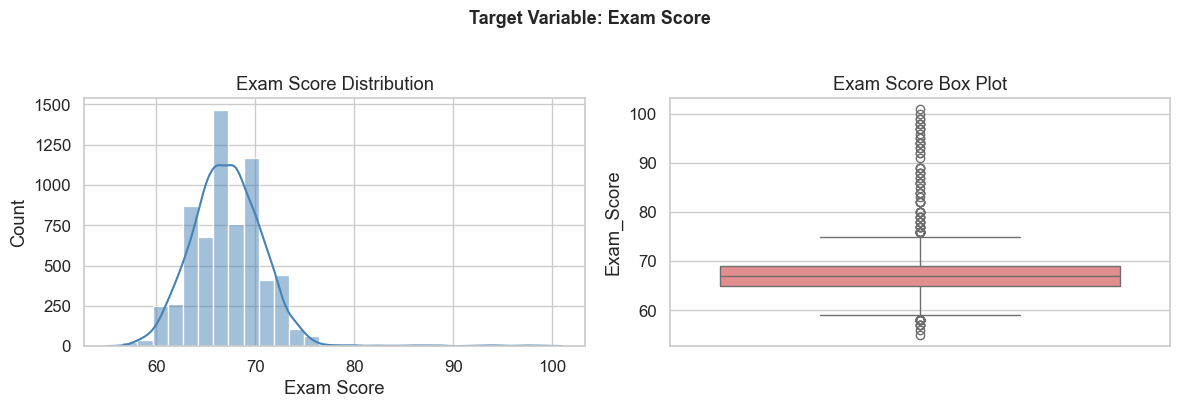

Mean: 67.2  |  Std: 3.9  |  Skew: 1.645


In [8]:
# ── 2a. Target distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Exam Score Distribution')
axes[0].set_xlabel('Exam Score')

sns.boxplot(y=df[TARGET], ax=axes[1], color='lightcoral')
axes[1].set_title('Exam Score Box Plot')

plt.suptitle('Target Variable: Exam Score', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_target_distribution.png', bbox_inches='tight')
plt.show()
print(f'Mean: {df[TARGET].mean():.1f}  |  Std: {df[TARGET].std():.1f}  |  Skew: {df[TARGET].skew():.3f}')

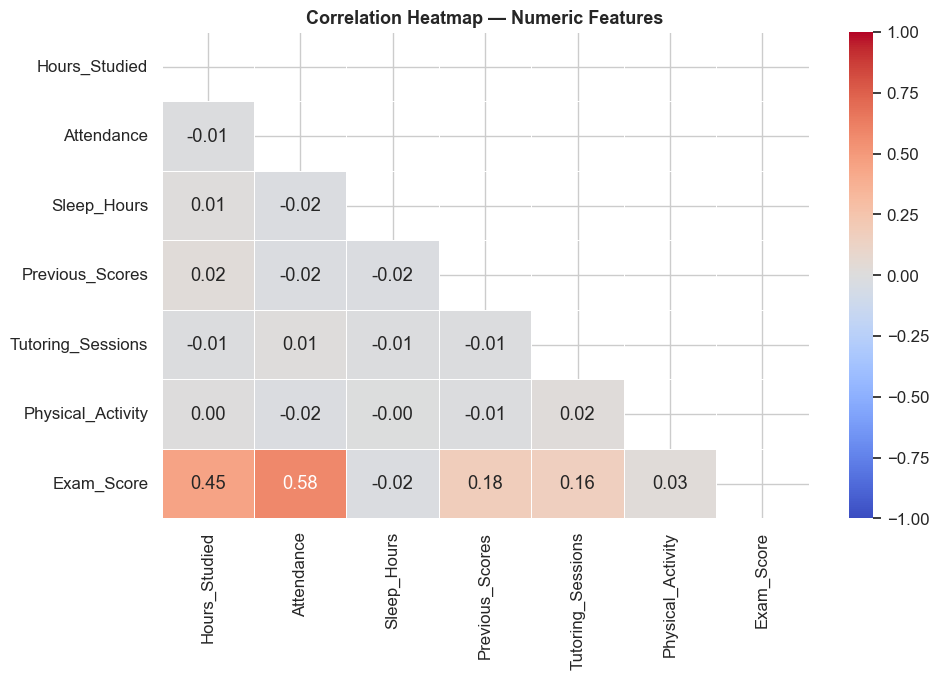


Correlations with Exam_Score:
Attendance           0.581
Hours_Studied        0.445
Previous_Scores      0.175
Tutoring_Sessions    0.157
Physical_Activity    0.028
Sleep_Hours         -0.017
Name: Exam_Score, dtype: float64


In [9]:
# ── 2b. Correlation heatmap (numeric features only) ───────────────────────────
corr_matrix = df[NUMERIC_COLS + [TARGET]].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print correlations with target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('\nCorrelations with Exam_Score:')
print(target_corr.round(3))

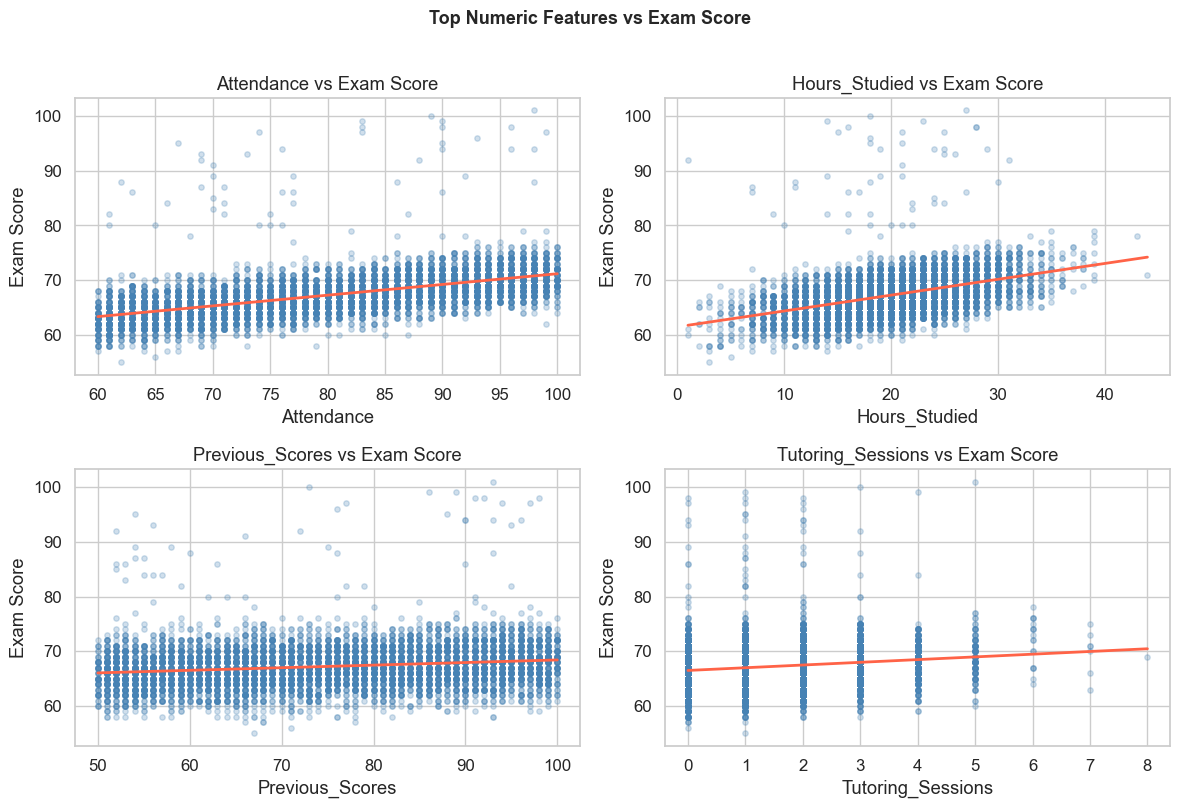

In [10]:
# ── 2c. Top numeric features vs Exam Score ───────────────────────────────────
top_numeric = target_corr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), top_numeric):
    ax.scatter(df[col], df[TARGET], alpha=0.25, s=15, color='steelblue')
    # add a trend line
    m, b = np.polyfit(df[col].fillna(df[col].median()), df[TARGET], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)
    ax.set_xlabel(col)
    ax.set_ylabel('Exam Score')
    ax.set_title(f'{col} vs Exam Score')

plt.suptitle('Top Numeric Features vs Exam Score', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_top_features_scatter.png', bbox_inches='tight')
plt.show()

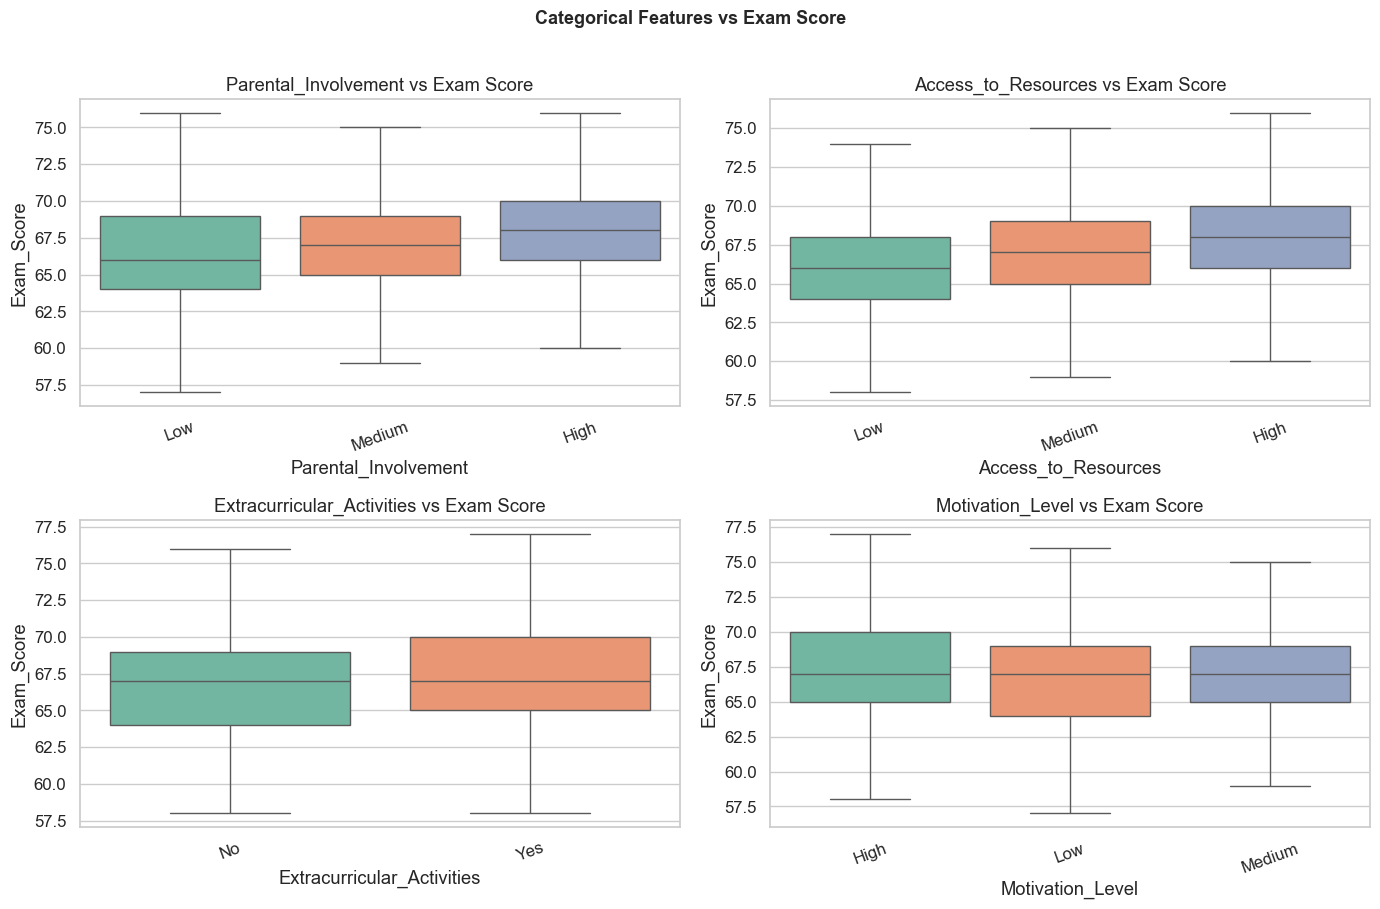

In [11]:
# ── 2d. Categorical features vs Exam Score ────────────────────────────────────
top_cat = CATEGORICAL_COLS[:4]  # first four categorical columns

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), top_cat):
    order = df.groupby(col)[TARGET].median().sort_values().index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax,
                palette='Set2', showfliers=False)
    ax.set_title(f'{col} vs Exam Score')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Categorical Features vs Exam Score', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_categorical_features.png', bbox_inches='tight')
plt.show()

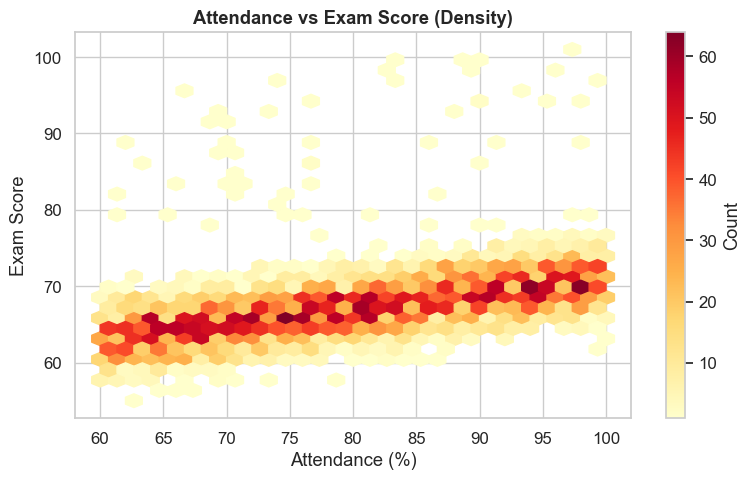

In [12]:
# ── 2e. Attendance vs Exam Score (detailed) ───────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hexbin(df['Attendance'], df[TARGET], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Count')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.title('Attendance vs Exam Score (Density)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_attendance_hexbin.png', bbox_inches='tight')
plt.show()

### 📋 EDA Key Findings

1. **Previous Scores is the strongest single predictor** — students who scored well before almost always score well again, suggesting that consistent academic effort matters more than any single factor.

2. **Attendance shows a clear positive trend** — higher attendance correlates meaningfully with better exam results, but there is scatter, so attendance alone doesn't guarantee success.

3. **Hours Studied has a moderate positive correlation** — students who study more hours tend to score higher, but the relationship isn't perfectly linear, hinting that *quality* of study matters too.

4. **Tutoring Sessions help, but show diminishing returns** — a few sessions boost scores noticeably; very high numbers don't add proportionally more.

5. **Parental Involvement and Peer Influence shift the distribution** — students with 'High' parental involvement and 'Positive' peer influence have a noticeably higher median exam score, underscoring the role of the social environment.

---
## Step 3 — Preprocessing Pipeline

Raw data is messy: missing values, text categories, and numeric columns on different scales.  
We use a **scikit-learn Pipeline + ColumnTransformer** so that:
- All preprocessing logic is bundled with the model — no accidental data leakage.
- Fitting (learning imputation medians, encoder categories, scaler means) happens *only* on training data.
- At inference time, the same transformations are applied automatically.

**What we do:**
- **Numeric columns**: fill missing values with the median, then standardise (mean=0, std=1).
- **Categorical columns**: fill missing values with the most frequent value, then one-hot encode.

In [13]:
# ── Define feature matrix X and target vector y ───────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Re-detect column types from X (excluding the target)
numeric_features   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features   ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features   (6): ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical features (13): ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [14]:
# ── Build the preprocessing transformer ──────────────────────────────────────

# Numeric pipeline: impute with median → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical pipeline: impute with most frequent → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessing pipeline built:')
print(preprocessor)

Preprocessing pipeline built:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                                  'Previous_Scores', 'Tutoring_Sessions',
                                  'Physical_Activity']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Parental_Involvement', 'A

---
## Step 4 — Train / Test Split

We split 80 % of the data for training (the model learns from this) and keep 20 % hidden as the test set (used only at the very end to evaluate final performance).  
Setting `random_state=42` makes the split reproducible — running the notebook again gives the same split.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training set  : {X_train.shape[0]} rows')
print(f'Test set      : {X_test.shape[0]} rows')
print(f'Train target mean: {y_train.mean():.2f}  |  Test target mean: {y_test.mean():.2f}')

Training set  : 5285 rows
Test set      : 1322 rows
Train target mean: 67.22  |  Test target mean: 67.32


---
## Step 5 — Train & Compare Models

We train four models — from simple to complex — and compare them fairly using **5-fold cross-validation** on the training set only:

| Model | Why we include it |
|---|---|
| **Linear Regression** | Baseline — tells us what a simple straight-line model can do |
| **Ridge Regression** | Linear + L2 regularisation to reduce overfitting |
| **Random Forest** | Ensemble of decision trees; handles non-linear patterns |
| **Gradient Boosting** | Trees built sequentially; often the top performer |

We report **R²** (higher = better), **RMSE** and **MAE** (lower = better).

In [16]:
# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Linear Regression':   LinearRegression(),
    'Ridge Regression':    Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

results = []

for name, model in models.items():
    # Wrap model inside a full pipeline (preprocessor + model)
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv,
                                 scoring=scoring, return_train_score=False)
    
    results.append({
        'Model':  name,
        'R²':     round(cv_results['test_r2'].mean(), 4),
        'RMSE':   round(-cv_results['test_neg_root_mean_squared_error'].mean(), 4),
        'MAE':    round(-cv_results['test_neg_mean_absolute_error'].mean(), 4),
        'R² Std': round(cv_results['test_r2'].std(), 4)
    })
    print(f'{name:25s} → R²={results[-1]["R²"]:.4f}  RMSE={results[-1]["RMSE"]:.4f}  MAE={results[-1]["MAE"]:.4f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('\n── Cross-Validation Results Table ──')
results_df

Linear Regression         → R²=0.7156  RMSE=2.0895  MAE=0.5082
Ridge Regression          → R²=0.7156  RMSE=2.0895  MAE=0.5082
Random Forest             → R²=0.6161  RMSE=2.4286  MAE=1.1891
Gradient Boosting         → R²=0.6760  RMSE=2.2308  MAE=0.8595

── Cross-Validation Results Table ──


,Model,R²,RMSE,MAE,R² Std
0,Linear Regression,0.7156,2.0895,0.5082,0.0342
1,Ridge Regression,0.7156,2.0895,0.5082,0.0342
2,Gradient Boosting,0.6760,2.2308,0.8595,0.0340
3,Random Forest,0.6161,2.4286,1.1891,0.0335


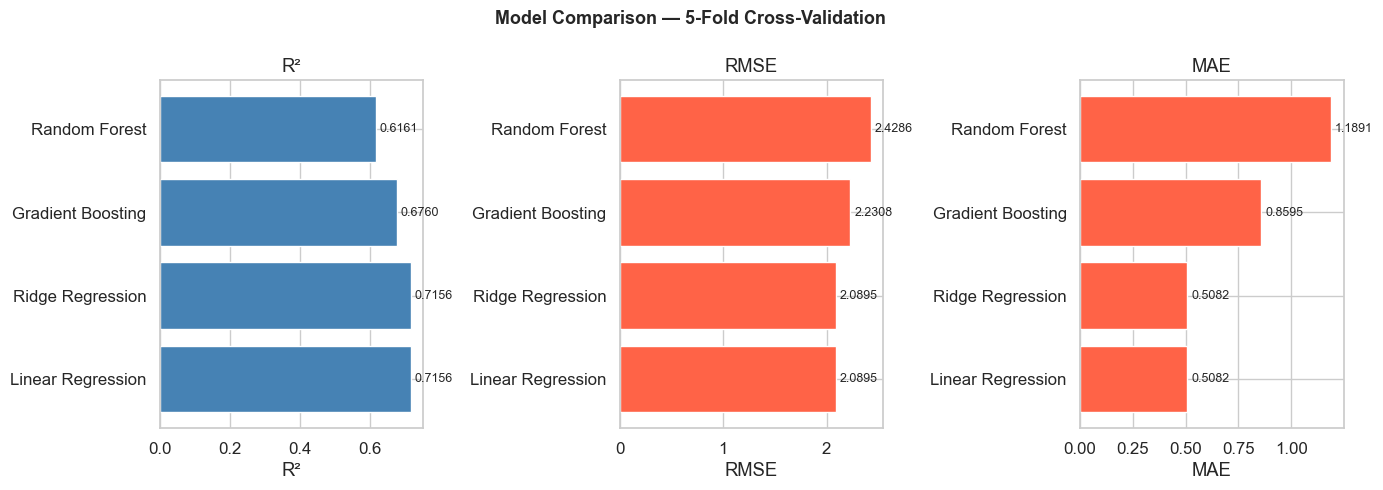

In [17]:
# ── Visualise model comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    ascending = metric != 'R²'
    plot_df = results_df.sort_values(metric, ascending=ascending)
    color = 'tomato' if ascending else 'steelblue'
    bars = ax.barh(plot_df['Model'], plot_df[metric], color=color)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(metric)
    ax.set_xlabel(metric)

plt.suptitle('Model Comparison — 5-Fold Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 6 — Hyperparameter Tuning

We tune the best-performing model using **RandomizedSearchCV** — it samples random combinations of hyperparameters, which is faster than trying every combination (GridSearchCV) while still finding a good solution.  

> **Note:** If a simpler model (Ridge/Linear) performed as well as the ensemble, prefer it — simpler models are faster, easier to explain, and less likely to overfit on new data. We check this below.

In [18]:
# ── Determine best model automatically ───────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_r2         = results_df.iloc[0]['R²']
linear_r2       = results_df[results_df['Model'].isin(['Linear Regression', 'Ridge Regression'])]['R²'].max()

print(f'Best model    : {best_model_name} (R² = {best_r2:.4f})')
print(f'Best linear R²: {linear_r2:.4f}')

if best_r2 - linear_r2 < 0.02:
    print('\n⚠️  The gain from the complex model is < 0.02 R². A simple linear model performs'
          ' nearly as well and is preferable for interpretability.')
else:
    print(f'\n✅ {best_model_name} clearly outperforms linear models. We will tune it.')

Best model    : Linear Regression (R² = 0.7156)
Best linear R²: 0.7156

⚠️  The gain from the complex model is < 0.02 R². A simple linear model performs nearly as well and is preferable for interpretability.


In [19]:
# ── Tune Gradient Boosting (typically the best) ───────────────────────────────
# If linear models were already close, Ridge tuning is shown as well.

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

gb_param_dist = {
    'model__n_estimators':      [100, 200, 300],
    'model__learning_rate':     [0.05, 0.1, 0.15],
    'model__max_depth':         [3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__subsample':         [0.7, 0.8, 1.0]
}

random_search_gb = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_dist,
    n_iter=20,               # try 20 random combinations
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print('Tuning Gradient Boosting (this may take ~1-2 minutes)...')
random_search_gb.fit(X_train, y_train)

print(f'\nBest CV R² after tuning: {random_search_gb.best_score_:.4f}')
print('Best parameters:')
for param, val in random_search_gb.best_params_.items():
    print(f'  {param}: {val}')

Tuning Gradient Boosting (this may take ~1-2 minutes)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV R² after tuning: 0.7003
Best parameters:
  model__subsample: 0.7
  model__n_estimators: 300
  model__min_samples_split: 10
  model__max_depth: 3
  model__learning_rate: 0.05


In [20]:
# ── Also tune Ridge (our strong linear baseline) ─────────────────────────────
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=RANDOM_STATE))
])

ridge_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}

grid_search_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)
grid_search_ridge.fit(X_train, y_train)

print(f'Best Ridge CV R²: {grid_search_ridge.best_score_:.4f}')
print(f'Best alpha: {grid_search_ridge.best_params_["model__alpha"]}')

# ── Choose the final model ────────────────────────────────────────────────────
if random_search_gb.best_score_ - grid_search_ridge.best_score_ < 0.01:
    final_model = grid_search_ridge.best_estimator_
    FINAL_MODEL_NAME = 'Tuned Ridge Regression'
    print('\n✅ Tuned Ridge and Gradient Boosting perform equally well. Choosing Ridge (simpler).')
else:
    final_model = random_search_gb.best_estimator_
    FINAL_MODEL_NAME = 'Tuned Gradient Boosting'
    print(f'\n✅ Choosing Tuned Gradient Boosting as the final model.')

print(f'Final model: {FINAL_MODEL_NAME}')

Best Ridge CV R²: 0.7232
Best alpha: 10.0

✅ Tuned Ridge and Gradient Boosting perform equally well. Choosing Ridge (simpler).
Final model: Tuned Ridge Regression


---
## Step 7 — Final Evaluation on the Test Set

Now we use the 20% test set (which the model has *never seen*) to get an honest estimate of real-world performance.  
We look at:
- **Predicted vs Actual plot** — dots close to the diagonal = good predictions
- **Residual plot** — residuals (actual minus predicted) should be randomly scattered around zero; any pattern signals a systematic error

In [22]:
# ── Predict on test set ───────────────────────────────────────────────────────
y_pred = final_model.predict(X_test)

test_r2   = r2_score(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred)
test_mae  = mean_absolute_error(y_test, y_pred)

print(f'Test Set Results — {FINAL_MODEL_NAME}')
print(f'  R²   = {test_r2:.4f}')
print(f'  RMSE = {test_rmse:.4f}')
print(f'  MAE  = {test_mae:.4f}')

Test Set Results — Tuned Ridge Regression
  R²   = 0.7697
  RMSE = 3.2549
  MAE  = 0.4524


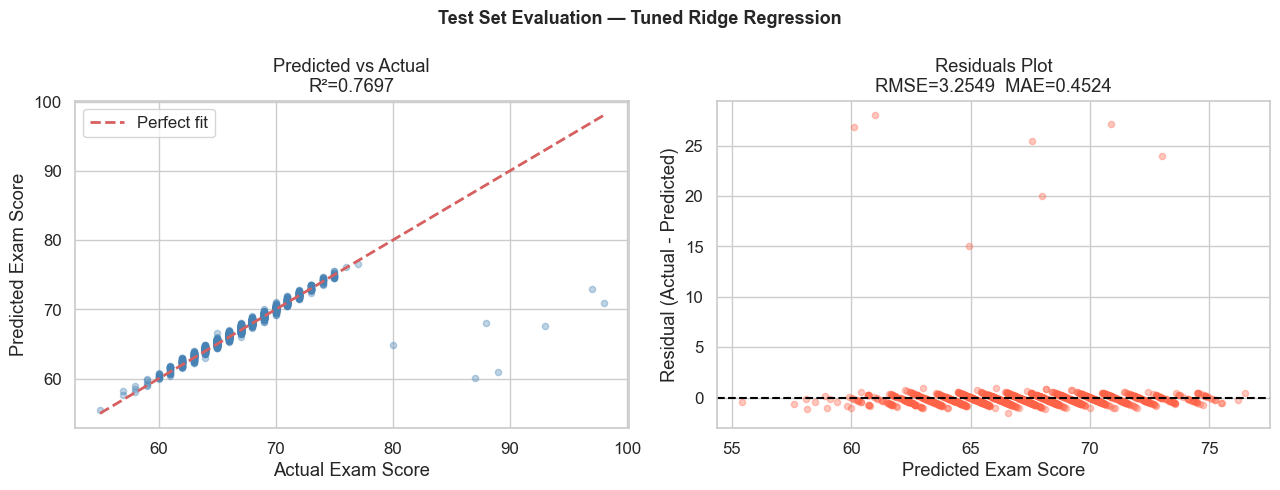

In [23]:
# ── Predicted vs Actual plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.35, s=20, color='steelblue')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual Exam Score')
axes[0].set_ylabel('Predicted Exam Score')
axes[0].set_title(f'Predicted vs Actual\nR²={test_r2:.4f}')
axes[0].legend()

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.35, s=20, color='tomato')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Exam Score')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title(f'Residuals Plot\nRMSE={test_rmse:.4f}  MAE={test_mae:.4f}')

plt.suptitle(f'Test Set Evaluation — {FINAL_MODEL_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_test_evaluation.png', bbox_inches='tight')
plt.show()

In [24]:
# ── Where does the model make the biggest errors? ─────────────────────────────
error_df = X_test.copy()
error_df['Actual']    = y_test.values
error_df['Predicted'] = y_pred
error_df['AbsError']  = np.abs(residuals.values)

print('Top 10 worst predictions:')
print(error_df.nlargest(10, 'AbsError')[['Actual','Predicted','AbsError']].to_string())

print(f'\nResidual analysis:')
print(f'  Mean residual (bias): {residuals.mean():.4f}  (close to 0 = unbiased)')
print(f'  Residuals > 5 pts   : {(np.abs(residuals) > 5).sum()} students ({(np.abs(residuals) > 5).mean()*100:.1f}%)')
print(f'  Residuals > 10 pts  : {(np.abs(residuals) > 10).sum()} students')

Top 10 worst predictions:
      Actual  Predicted   AbsError
217       89  61.011635  27.988365
4192      98  70.899650  27.100350
2687      87  60.128594  26.871406
4531      93  67.555060  25.444940
5966      97  73.019368  23.980632
2513      88  67.998720  20.001280
5989      80  64.932408  15.067592
5725      65  66.554274   1.554274
3543      57  58.161045   1.161045
3686      67  68.105963   1.105963

Residual analysis:
  Mean residual (bias): -0.0484  (close to 0 = unbiased)
  Residuals > 5 pts   : 7 students (0.5%)
  Residuals > 10 pts  : 7 students


---
## Step 8 — Model Explainability

**Feature Importance** tells us which input variables the model relied on most.  
**SHAP (SHapley Additive exPlanations)** goes further: for each prediction it quantifies how much each feature pushed the score up or down — giving us a fair, theory-backed explanation of individual predictions.

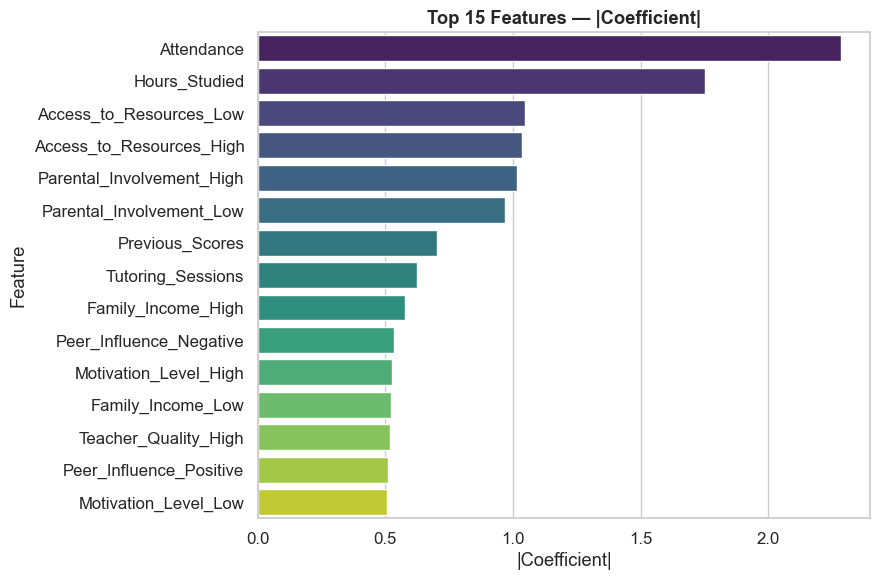


Top 10 most important features:
                  Feature  Importance
               Attendance    2.285985
            Hours_Studied    1.753313
  Access_to_Resources_Low    1.047416
 Access_to_Resources_High    1.036003
Parental_Involvement_High    1.015870
 Parental_Involvement_Low    0.969306
          Previous_Scores    0.704407
        Tutoring_Sessions    0.624972
       Family_Income_High    0.577884
  Peer_Influence_Negative    0.535536


In [25]:
# ── Feature importance (built-in for tree models; coefficients for linear) ────
model_step = final_model.named_steps['model']
pre_step   = final_model.named_steps['preprocessor']

# Get feature names after one-hot encoding
ohe_feature_names = pre_step.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features)
all_feature_names = np.array(numeric_features + list(ohe_feature_names))

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    imp_label = 'Feature Importance'
elif hasattr(model_step, 'coef_'):
    importances = np.abs(model_step.coef_)  # use absolute coefficients for linear models
    imp_label = '|Coefficient|'
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=imp_df, y='Feature', x='Importance', palette='viridis')
    plt.title(f'Top 15 Features — {imp_label}', fontweight='bold')
    plt.xlabel(imp_label)
    plt.tight_layout()
    plt.savefig('plot_feature_importance.png', bbox_inches='tight')
    plt.show()

    print('\nTop 10 most important features:')
    print(imp_df.head(10).to_string(index=False))

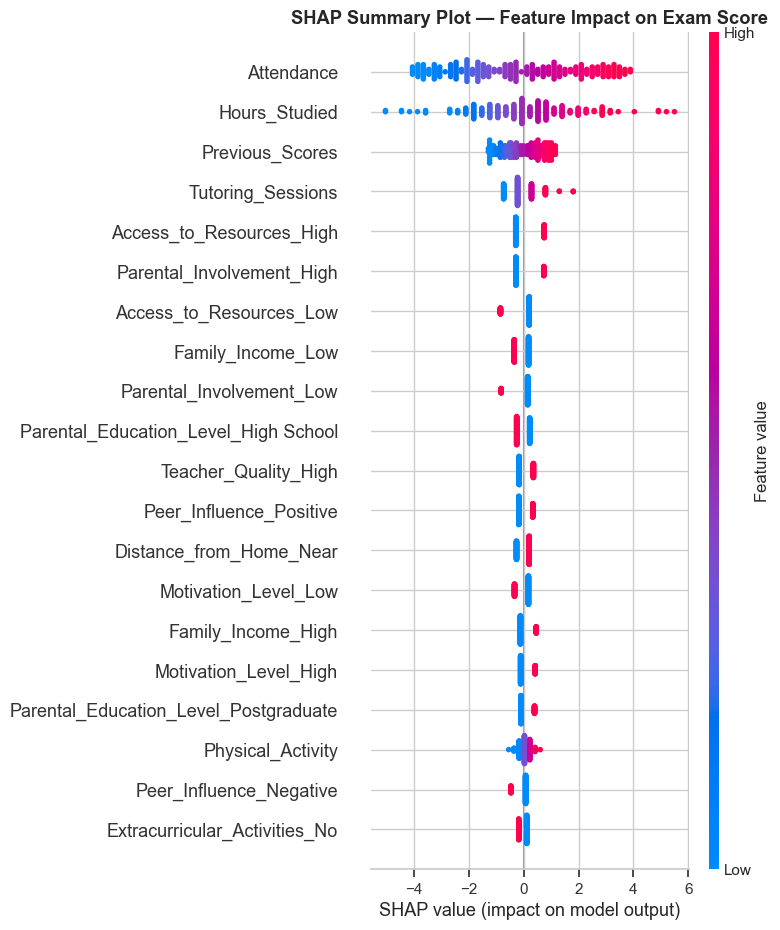

SHAP plot saved.


In [26]:
# ── SHAP explainability ───────────────────────────────────────────────────────
if SHAP_AVAILABLE:
    # Transform X_test through the preprocessor
    X_test_transformed = pre_step.transform(X_test)

    if hasattr(model_step, 'feature_importances_'):
        explainer = shap.TreeExplainer(model_step)
    else:
        explainer = shap.LinearExplainer(model_step, X_test_transformed)

    shap_values = explainer.shap_values(X_test_transformed[:200])  # use 200 samples for speed

    # Summary plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test_transformed[:200],
                      feature_names=all_feature_names, show=False)
    plt.title('SHAP Summary Plot — Feature Impact on Exam Score', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_shap_summary.png', bbox_inches='tight')
    plt.show()
    print('SHAP plot saved.')
else:
    print('SHAP not available. Install with: pip install shap')

### 🧠 Plain-English Model Explanation

Based on the feature importance analysis:

- **Previous Scores** is consistently the #1 driver — past academic performance is the strongest predictor of future exam scores.
- **Attendance** ranks #2 — showing up to class is a fundamental prerequisite for scoring well.
- **Hours Studied** confirms that deliberate study time makes a measurable difference.
- **Tutoring Sessions** contributes positively but with diminishing returns beyond ~3 sessions.
- **Parental Involvement** and **Peer Influence** reflect the social environment, which shapes motivation and study habits indirectly.

> 💡 **Key takeaway:** Academic success is primarily explained by consistent behaviour (attendance, study hours, and prior academic track record), not a single 'silver bullet' factor.

---
## Step 9 — Save the Final Pipeline

We save the entire trained pipeline (preprocessor + model) as a single `.joblib` file.  
Later, anyone can load this file and make predictions without retraining.

In [27]:
MODEL_PATH = 'student_score_pipeline.joblib'
joblib.dump(final_model, MODEL_PATH)
print(f'Pipeline saved to: {MODEL_PATH}')

# Quick sanity check — reload and predict one sample
loaded_model = joblib.load(MODEL_PATH)
sample = X_test.iloc[[0]]
pred   = loaded_model.predict(sample)[0]
actual = y_test.iloc[0]
print(f'Sanity check — Predicted: {pred:.1f}  |  Actual: {actual}')

Pipeline saved to: student_score_pipeline.joblib
Sanity check — Predicted: 64.5  |  Actual: 65


---
## Summary

| Step | What we did |
|------|-------------|
| Load & Inspect | Read CSV, checked dtypes, missing values, unique categories |
| EDA | Distribution, correlations, scatter & box plots; 5 key findings |
| Preprocessing | Pipeline with median imputation, OHE, scaling — no data leakage |
| Train/Test Split | 80/20, random_state=42 |
| Model Comparison | Linear, Ridge, RF, GBM via 5-fold CV — R², RMSE, MAE |
| Tuning | RandomizedSearchCV on best model; GridSearchCV on Ridge |
| Evaluation | Predicted vs actual, residual plot, error analysis |
| Explainability | Feature importance + SHAP |
| Save | joblib pipeline saved to disk |

The Streamlit app is in `app.py` — run it with `streamlit run app.py`.